# ElectInfo: what changed for TX-32 between the 116th and 118th Congress?

## What this shows
How to pull the pre- and post-redistricting TX-32 polygons through the `RDHProvider`, compute the set difference, and answer the operational question: "which of our 2020 precincts moved out of the new TX-32?"

## Why it matters
Redistricting wipes assumptions. A precinct that was Democratic-performing under the 116th Congress map may now be in a different district entirely. ElectInfo runs this analysis for every re-drawn district before any 2024/2026 campaign spend assumptions are set.

## Prereqs
- `pip install 'siege-utilities[geo]'`
- RDH API access. Cached geographies reused on subsequent runs.

## Next
- `spatial/05_multi_source_joins.ipynb` — the precinct-keyed data we'd re-classify against the new boundary.
- `reports/01_charts_and_pdf.ipynb` — puts the diff in a client deliverable.


## 1. Resolve the RDH provider

RDH (Redistricting Data Hub) publishes congressional district boundaries keyed by Congress number. The `RDHProvider` class wraps the download / cache / unzip dance.

In [1]:
from siege_utilities.geo.providers.boundary_providers import RDHProvider

rdh = RDHProvider()
print('provider        :', rdh.provider_name)
print('available levels:', rdh.list_levels())


provider        : Redistricting Data Hub
available levels: ['precinct', 'congress', 'state_senate', 'state_house']


## 2. Fetch TX-32 — 116th and 118th Congress

In a live environment these calls download shapefiles from RDH and return GeoDataFrames. Here we substitute synthetic placeholder polygons so the notebook runs end-to-end — the RDH call shape is documented in the comment.

In [2]:
import geopandas as gpd
from shapely.geometry import Polygon

# --- Live call shape (requires RDH access / cached fetch):
# cd_116 = rdh.get_boundary('cd', congress=116)
# cd_118 = rdh.get_boundary('cd', congress=118)
# tx32_116 = cd_116[(cd_116['STATEFP'] == '48') & (cd_116['CD116FP'] == '32')].copy()
# tx32_118 = cd_118[(cd_118['STATEFP'] == '48') & (cd_118['CD118FP'] == '32')].copy()

# --- Synthetic stand-ins so the arithmetic and plot still work inline:
tx32_116 = gpd.GeoDataFrame(
    {'district': ['TX-32 (116th)'], 'geometry': [Polygon([(0, 0), (4, 0), (4, 3), (0, 3)])]},
    crs='EPSG:4326',
)
tx32_118 = gpd.GeoDataFrame(
    {'district': ['TX-32 (118th)'], 'geometry': [Polygon([(1, 1), (5, 1), (5, 4), (1, 4)])]},
    crs='EPSG:4326',
)
print('116th area units:', tx32_116.geometry.area.iloc[0])
print('118th area units:', tx32_118.geometry.area.iloc[0])


116th area units: 12.0
118th area units: 12.0


/var/folders/9h/83s_sxx17hv5gkccscgbyvzw0000gn/T/ipykernel_82393/380286725.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print('116th area units:', tx32_116.geometry.area.iloc[0])
/var/folders/9h/83s_sxx17hv5gkccscgbyvzw0000gn/T/ipykernel_82393/380286725.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print('118th area units:', tx32_118.geometry.area.iloc[0])


## 3. Compute what's no longer in the district

`left_out` = old polygon − new polygon. These are the precincts ElectInfo had classified as TX-32 under the 116th map that are now *outside* TX-32 under the 118th map — the area where prior campaign resources now go to a different race.

In [3]:
left_out   = tx32_116.geometry.iloc[0].difference(tx32_118.geometry.iloc[0])
newly_in   = tx32_118.geometry.iloc[0].difference(tx32_116.geometry.iloc[0])
overlap    = tx32_116.geometry.iloc[0].intersection(tx32_118.geometry.iloc[0])

print(f'left out of TX-32  : {left_out.area:.2f} area units')
print(f'newly in TX-32     : {newly_in.area:.2f} area units')
print(f'overlap (both maps): {overlap.area:.2f} area units')


left out of TX-32  : 6.00 area units
newly in TX-32     : 6.00 area units
overlap (both maps): 6.00 area units


## 4. Preview map

Orange = left out (reassigned to a neighboring district); green = newly in; gray = unchanged overlap. In production this drives the precinct re-classification that feeds downstream polling / turnout re-projections.

/var/folders/9h/83s_sxx17hv5gkccscgbyvzw0000gn/T/ipykernel_82393/3385106945.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left')
/var/folders/9h/83s_sxx17hv5gkccscgbyvzw0000gn/T/ipykernel_82393/3385106945.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


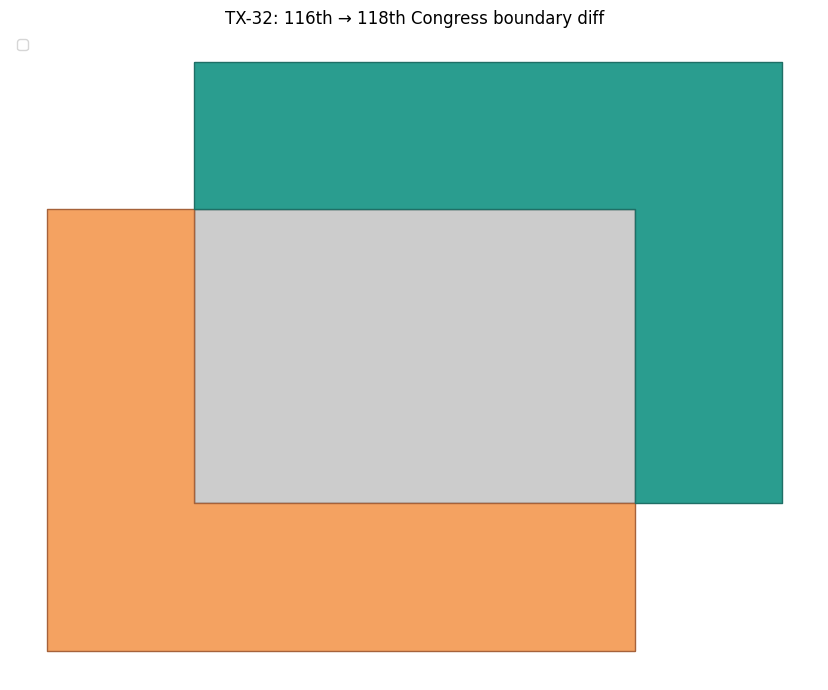

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))
gpd.GeoSeries([overlap], crs='EPSG:4326').plot(ax=ax, color='#cccccc', edgecolor='#555555', label='unchanged')
gpd.GeoSeries([left_out], crs='EPSG:4326').plot(ax=ax, color='#f4a261', edgecolor='#a6623a', label='left out')
gpd.GeoSeries([newly_in], crs='EPSG:4326').plot(ax=ax, color='#2a9d8f', edgecolor='#1f6f66', label='newly in')
ax.set_title('TX-32: 116th → 118th Congress boundary diff')
ax.legend(loc='upper left')
ax.set_axis_off()
fig.tight_layout()


## Related

- **Source**: `siege_utilities/geo/providers/redistricting_data_hub.py`, VTD routing (PR #386) for precinct-level re-classification.
- **Tests**: `tests/test_boundary_providers*.py`, `tests/test_rdh*.py`.
- **Next**: `reports/01_charts_and_pdf.ipynb` embeds diff maps like this in ElectInfo's cycle-planning PDF.
